In [ ]:
import os, sys
from pathlib import Path
from dotenv import load_dotenv

print(sys.executable)          # ai-server\.venv 경로여야 정상

load_dotenv(Path("..") / ".env")
KEY = os.getenv("KIPRIS_API_KEY")
print("키 로드:", bool(KEY))

In [ ]:
from pathlib import Path

p = Path("..") / ".env"
print("찾는 경로:", p.resolve())
print("존재 여부:", p.exists())

if p.exists():
    print("---내용---")
    print(p.read_text(encoding="utf-8"))

In [ ]:
print("키 로드:", bool(KEY))

In [ ]:
from pathlib import Path

base = Path("..") / "data" / "trademarks" / "raw"

for p in sorted(base.rglob("*"))[:40]:
    if p.is_file():
        print(p.relative_to(base), f"{p.stat().st_size/1024:.1f}KB")

In [ ]:
base = Path("..") / "data" / "trademarks"

In [ ]:
from pathlib import Path

base = Path("..") / "data" / "trademarks" / "raw"

for p in sorted(base.rglob("*"))[:40]:
    if p.is_file():
        print(p.relative_to(base), f"{p.stat().st_size/1024:.1f}KB")

In [ ]:
from pathlib import Path

base = Path("..") / "data"
print("절대경로:", base.resolve())

for p in sorted(base.rglob("*"))[:50]:
    print(("[D] " if p.is_dir() else "    ") + str(p.relative_to(base)))

In [ ]:
txt_files = sorted(base.rglob("TXT/*"))
print("TXT 파일 수:", len(txt_files))
for f in txt_files[:10]:
    print(f.name, f"{f.stat().st_size/1024:.1f}KB")

In [ ]:
target = txt_files[0]

for enc in ["utf-8", "cp949"]:
    try:
        with open(target, encoding=enc) as f:
            lines = [next(f).rstrip() for _ in range(3)]
        print(f"=== {enc} 성공 ===")
        for l in lines:
            print(l[:300])
        break
    except (UnicodeDecodeError, StopIteration) as e:
        print(f"{enc} 실패: {type(e).__name__}")

In [ ]:
for f in txt_files:
    with open(f, encoding="utf-8") as fh:
        header = fh.readline().rstrip()
    print(f"■ {f.name}")
    print("  ", header.replace("\x02", " | ")[:250])
    print()

In [ ]:
import pandas as pd

def load(name):
    f = next(p for p in txt_files if p.name == name)
    return pd.read_csv(f, sep="\x02", encoding="utf-8", engine="python", dtype=str)

kt10 = load("TB_KT10.txt")
print(kt10.shape)
print(kt10.columns.tolist())

print("\n[최종처분코드명]")
print(kt10["최종처분코드명"].value_counts())

print("\n[상표유형코드명]")
print(kt10["상표유형코드명"].value_counts())

print("\n[상표이미지유무]")
print(kt10["상표이미지유무"].value_counts())

In [ ]:
import pandas as pd

SEP = chr(2)   # \x02

def load(name):
    f = next(p for p in txt_files if p.name == name)
    with open(f, encoding="utf-8") as fh:
        rows = [line.rstrip("\n").split(SEP) for line in fh]
    header, data = rows[0], rows[1:]
    # 행마다 길이가 다를 수 있으니 헤더 길이에 맞춤
    data = [r[:len(header)] + [None] * (len(header) - len(r)) for r in data]
    return pd.DataFrame(data, columns=header, dtype=str)

kt10 = load("TB_KT10.txt")
print(kt10.shape)
print(kt10.columns.tolist()[:12])
kt10.head(3)

In [ ]:
f = next(p for p in txt_files if p.name == "TB_KT10.txt")
with open(f, "rb") as fh:
    raw = fh.read(200)
print(raw)

In [ ]:
import pandas as pd

def load(name, sep="^B"):
    f = next(p for p in txt_files if p.name == name)
    with open(f, encoding="utf-8") as fh:
        rows = [line.rstrip("\n").split(sep) for line in fh]
    header, data = rows[0], rows[1:]
    data = [r[:len(header)] + [None] * (len(header) - len(r)) for r in data]
    return pd.DataFrame(data, columns=header)

kt10 = load("TB_KT10.txt")
print(kt10.shape)
kt10.head(3)

In [ ]:
for col in ["최종처분코드명", "상표유형코드명", "상표이미지유무", "법적상태"]:
    print(f"\n[{col}]")
    print(kt10[col].value_counts(dropna=False))

In [ ]:
print(kt10["상표구분코드명"].value_counts(dropna=False))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_dir = next(p for p in base.rglob("IMG") if p.is_dir())

def show(gubun, n=4):
    nos = kt10[kt10["상표구분코드명"] == gubun]["출원번호"].head(n)
    fig, axes = plt.subplots(1, n, figsize=(12, 3))
    for ax, no in zip(axes, nos):
        f = next(img_dir.glob(f"{no}_*"), None)
        if f:
            ax.imshow(Image.open(f)); ax.set_title(no[-6:], fontsize=8)
        ax.axis("off")
    fig.suptitle(gubun)
    plt.show()
for g in ["도형복합", "복합문자", "영문상표"]:
    show(g)

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_dir = next(p for p in base.rglob("IMG") if p.is_dir())

def show(gubun, n=4):
    nos = kt10[kt10["상표구분코드명"] == gubun]["출원번호"].head(n)
    fig, axes = plt.subplots(1, n, figsize=(12, 3))
    for ax, no in zip(axes, nos):
        f = next(img_dir.glob(f"{no}_*"), None)
        if f:
            ax.imshow(Image.open(f)); ax.set_title(no[-6:], fontsize=8)
        ax.axis("off")
    fig.suptitle(gubun)
    plt.show()

for g in ["도형복합", "복합문자", "영문상표"]:
    show(g)

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 모든 IMG 폴더의 이미지를 출원번호로 인덱싱
img_map = {}
for f in base.rglob("IMG/*"):
    no = f.stem.split("_")[0]
    img_map[no] = f

print("인덱싱된 이미지:", len(img_map))

# 매칭 확인
matched = kt10["출원번호"].isin(img_map).sum()
print(f"kt10 {len(kt10)}건 중 이미지 매칭: {matched}건")

In [ ]:
# kt10을 어느 폴더에서 읽었는지 확인
print([p for p in txt_files if p.name == "TB_KT10.txt"])

# 폴더별 이미지 수
from collections import Counter
print(Counter(f.parent.parent.name for f in base.rglob("IMG/*")))

In [ ]:
for d in sorted(base.rglob("DBII_*")):
    if d.is_dir():
        txts = list(d.rglob("TXT/*"))
        imgs = list(d.rglob("IMG/*"))
        print(f"{d.name}: TXT {len(txts)}개, IMG {len(imgs)}개")
        print("   ", [t.name for t in txts][:8])

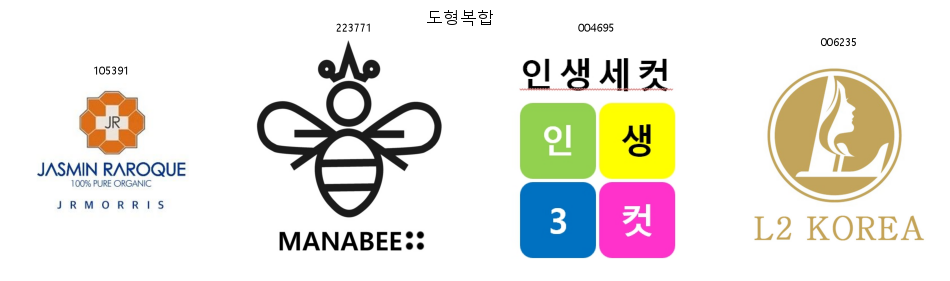

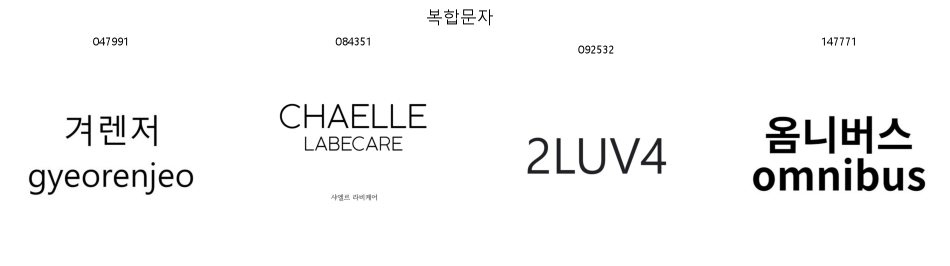

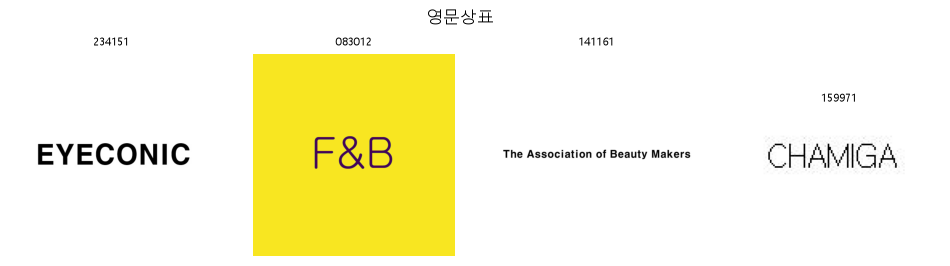

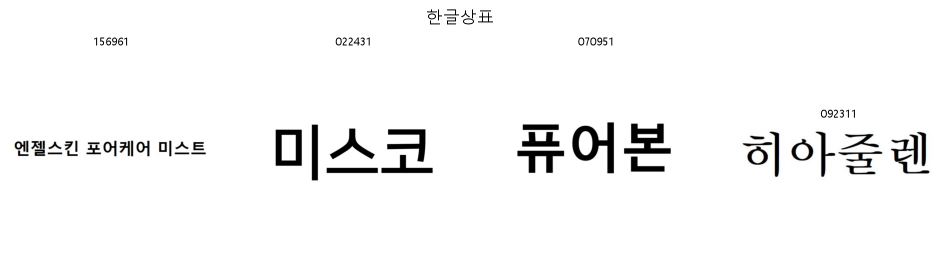

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 출원번호 → 이미지 경로
img_map = {f.stem.split("_")[0]: f for f in base.rglob("IMG/*")}

def show(gubun, n=4):
    nos = [x for x in kt10[kt10["상표구분코드명"] == gubun]["출원번호"] if x in img_map][:n]
    if not nos:
        print(f"{gubun}: 매칭 이미지 없음")
        return
    fig, axes = plt.subplots(1, len(nos), figsize=(3 * len(nos), 3))
    if len(nos) == 1:
        axes = [axes]
    for ax, no in zip(axes, nos):
        ax.imshow(Image.open(img_map[no]))
        ax.set_title(no[-6:], fontsize=8)
        ax.axis("off")
    fig.suptitle(gubun)
    plt.show()

for g in ["도형복합", "복합문자", "영문상표", "한글상표"]:
    show(g)